# Sentiment Analysis using ML models

### Import Libraries

In [9]:
# data handling 
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# text processing
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Load Dataset

In [10]:
# load the csv file
df = pd.read_csv("sentimentdataset.csv")

# display
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


### Initial Data Inspection

In [15]:
# dataset info
print("\n Data Information:")
df.info()


 Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [16]:
# check missing values
print("\n Missing Values:")
df.isnull().sum()


 Missing Values:


Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [17]:
# Quick statistical summary of numerical columns
print("\n Numerical Summary:")
df.describe()


 Numerical Summary:


,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [18]:
# check unique sentiment labels
print("\n Unique Sentiment:")
df['Sentiment'].value_counts()


 Unique Sentiment:


Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

### Exploratory Data Analysis(EDA)

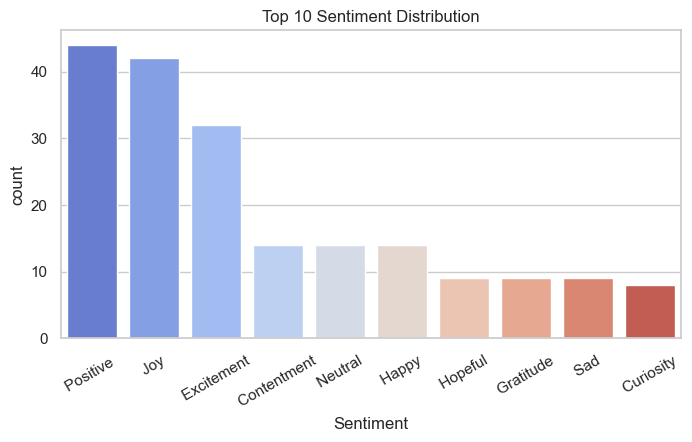

In [23]:
# get the top 10 sentiments by count
top_sentiments = df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# Sentiment Distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df_top, x='Sentiment', palette='coolwarm', order=top_sentiments)
plt.title("Top 10 Sentiment Distribution")
plt.xticks(rotation=30)
plt.show()

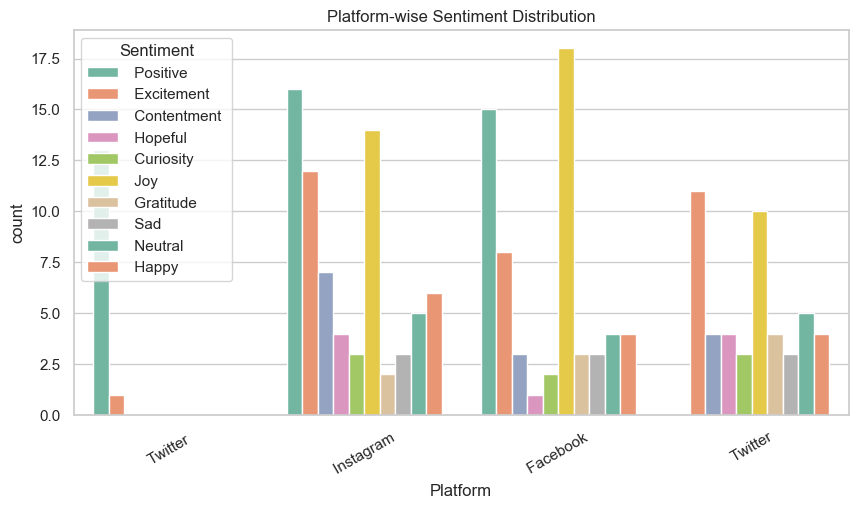

In [24]:
# Platform-wise Sentiment Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, x='Platform', hue='Sentiment', palette='Set2')
plt.title('Platform-wise Sentiment Distribution')
plt.xticks(rotation=30)
plt.show()

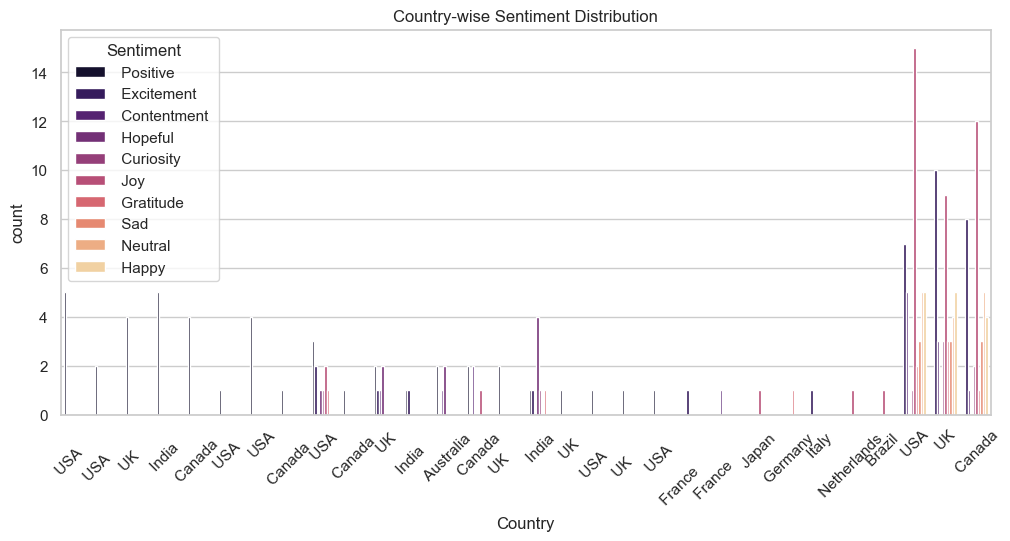

In [27]:
# Country-wise Sentiment Distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df_top, x='Country', hue='Sentiment', palette='magma')
plt.title('Country-wise Sentiment Distribution')
plt.xticks(rotation=45)
plt.show()

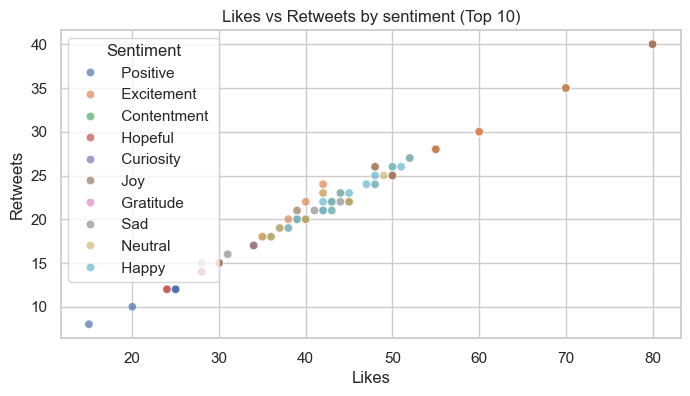

In [29]:
# Likes vs Re-tweets
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_top, x='Likes', y='Retweets', hue='Sentiment', alpha=0.7)
plt.title('Likes vs Retweets by sentiment (Top 10)')
plt.show()

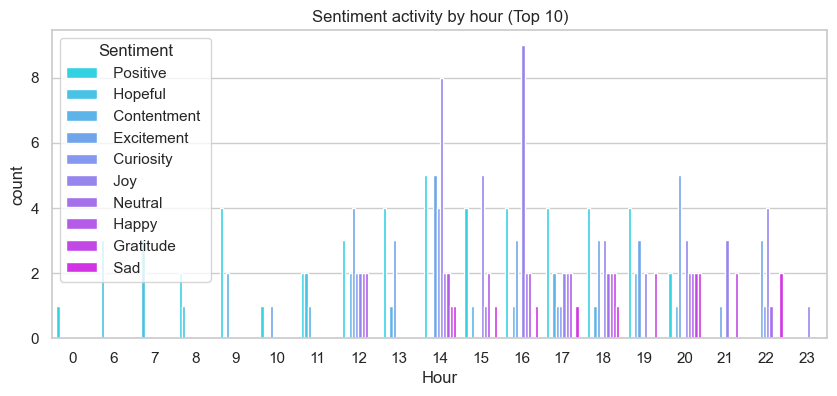

In [30]:
# Sentiment Trend over Hours
plt.figure(figsize=(10, 4))
sns.countplot(data=df_top, x='Hour', hue='Sentiment', palette='cool')
plt.title('Sentiment activity by hour (Top 10)')
plt.show()

### Text Cleaning & Preprocessing

In [31]:
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+","", text)   # remove URLs
    text = re.sub(r"@\w+","", text)      # remove mentions
    text = re.sub(r"#\w+","", text)      # remove hastags
    text = re.sub(r"[^a-z\s]","", text) # keep only letters
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text.strip()

df['Clean_Text'] = df['Text'].apply(clean_text)
df[['Text', 'Clean_Text']].head(10)

,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little things life
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussions heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibes beach days


### Text Analysis

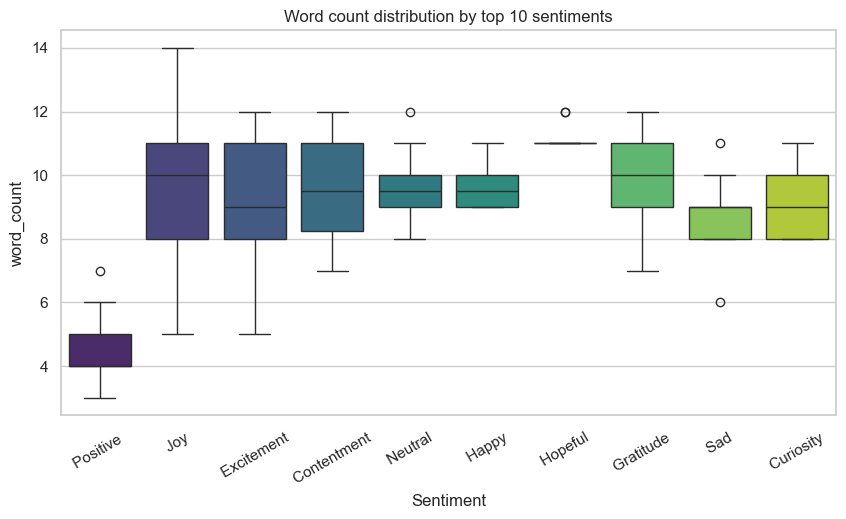


Top words for  Positive  :


,word,Frequency
0,new,10
1,day,4
2,weekend,4
3,feeling,4
4,enjoying,3



Top words for  Joy :


,word,Frequency
0,music,7
1,art,7
2,joy,6
3,every,6
4,attended,6



Top words for  Excitement :


...

,word,Frequency
0,gratitude,3
1,story,3
2,writing,3
3,every,3
4,thankfulness,2



Top words for  Sad :


,word,Frequency
0,feeling,5
1,challenges,2
2,sometimes,2
3,unexpected,2
4,missing,2



Top words for  Curiosity :


,word,Frequency
0,new,4
1,curiosity,2
2,art,2
3,learning,2
4,unveiling,1


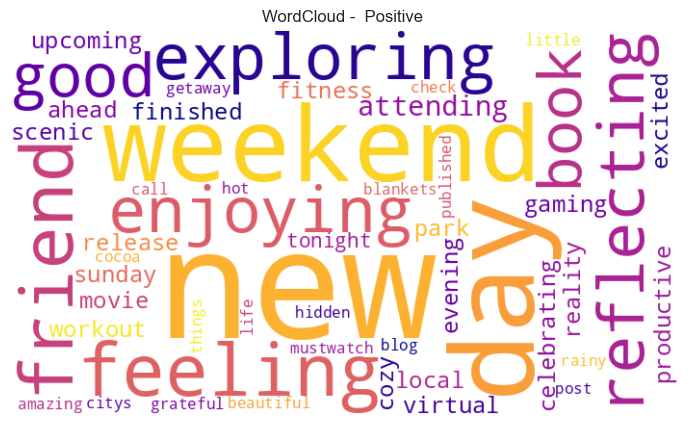

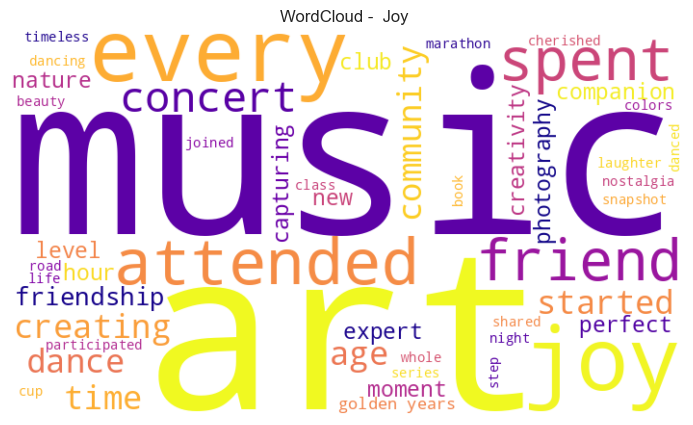

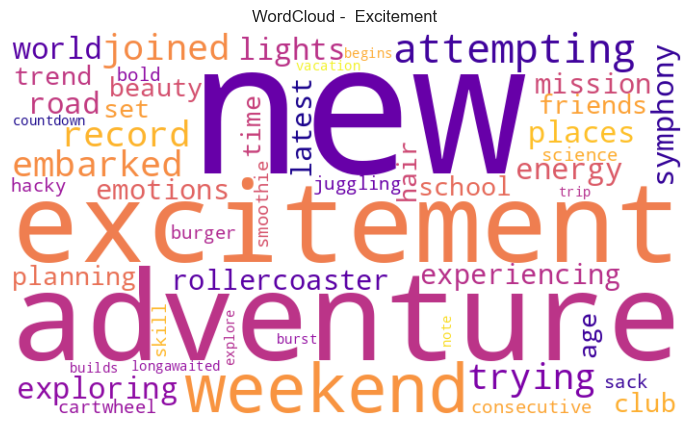

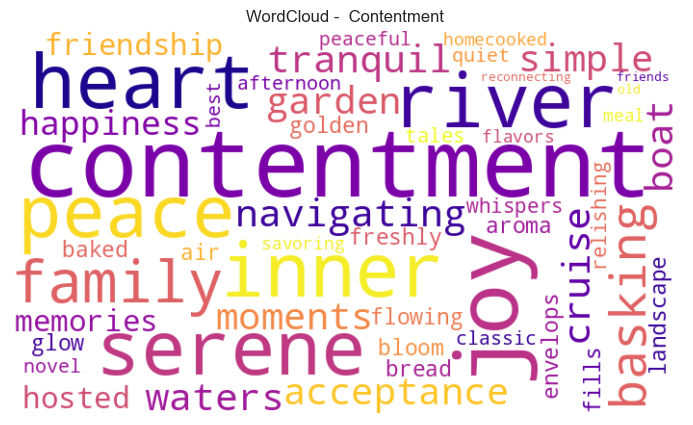

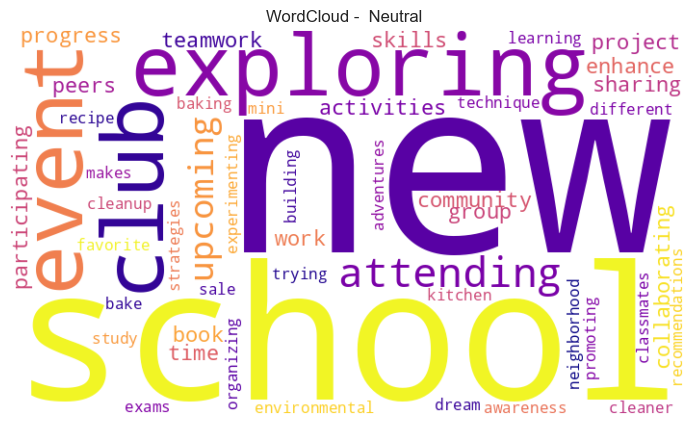

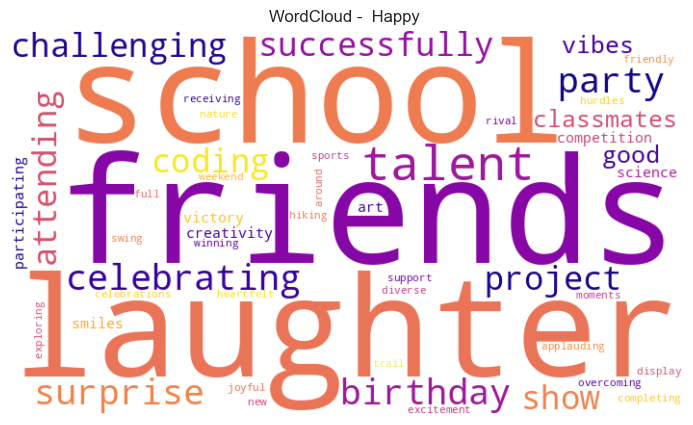

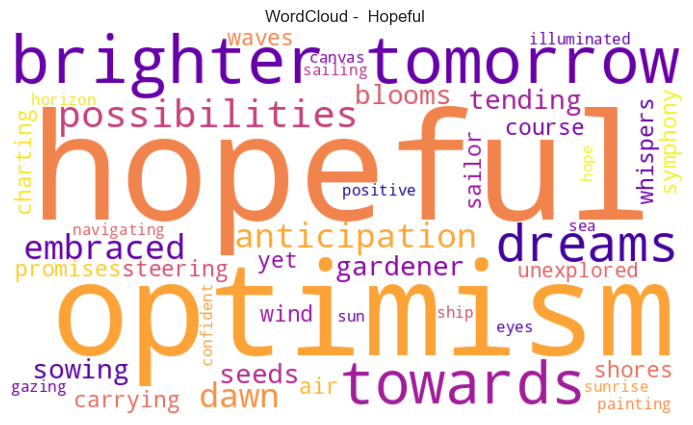

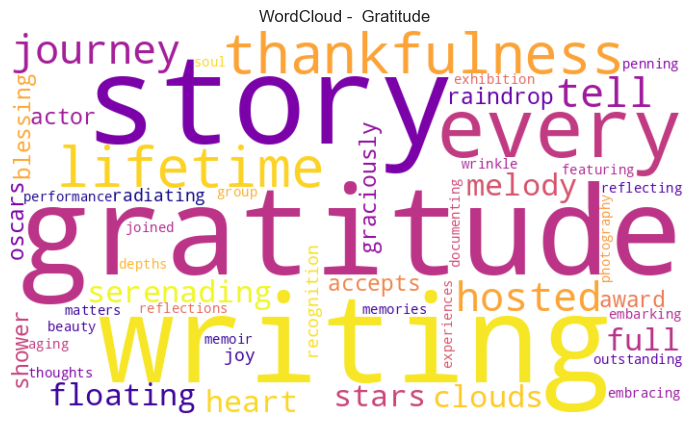

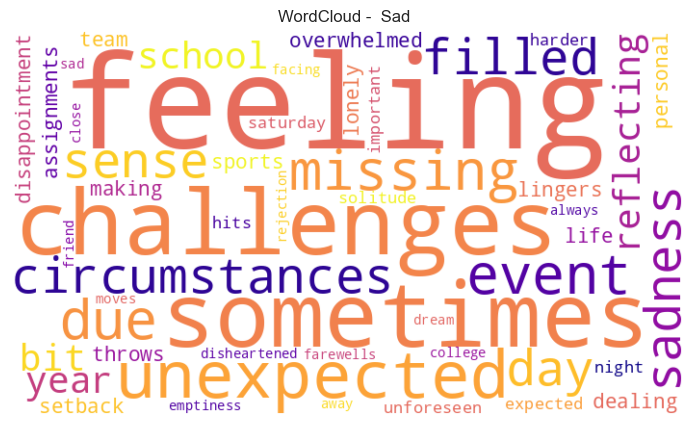

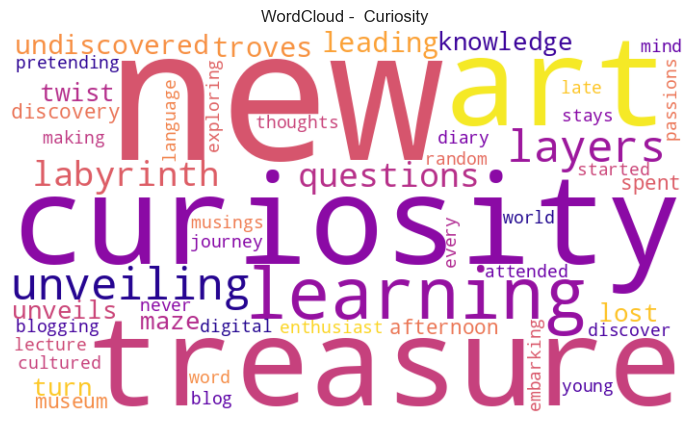

In [37]:
# select top 10 more frequent sentiments
top_sentiments = df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# average the word count per sentiment (top 10)
df_top['word_count'] = df_top['Clean_Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_top, x='Sentiment', y='word_count', palette='viridis', order=top_sentiments)
plt.title('Word count distribution by top 10 sentiments')
plt.xticks(rotation=30)
plt.show()

# Most common words per sentiment (Top 10 sentiments, top 5 words each)
def most_common_words(sentiment, n=5):
    words = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text']).split()
    common = Counter(words).most_common(n)
    return pd.DataFrame(common, columns=['word', 'Frequency'])

for s in top_sentiments:
    print(f"\nTop words for {s}:")
    display(most_common_words(s, n=5))

# WordClouds for Top 10 Sentiments
for sentiment in top_sentiments:
    text = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text'])
    wc = WordCloud(width=700, height=400, background_color='white', colormap='plasma', max_words=50).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

# Feature extraction

In [41]:
# Combine rare classes with <2 samples into 'Other'
counts = df['Sentiment'].value_counts()
rare_classes = counts[counts < 2].index
df['Sentiment'] = df['Sentiment'].replace(rare_classes, 'other')

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=  150000,
    ngram_range= (1, 3),
    min_df= 2,
    max_df= 0.95
)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Sentiment']

# train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)
print("Train Shape:", X_train.shape, "Test Shape:", X_test.shape)

Train Shape: (585, 1758) Test Shape: (147, 1758)


### Model training and comparision

In [52]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    

Logistic Regression Accuracy: 0.2177
Naive Bayes Accuracy: 0.1973
Linear SVM Accuracy: 0.4626
Random Forest Accuracy: 0.4354


### visual comparisons of model accuracies

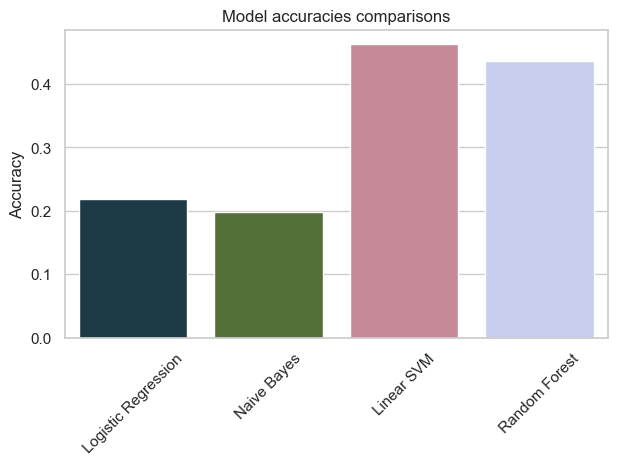


 Best Performing Model: Linear SVM (46.26% accuracy)


In [54]:
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='cubehelix')
plt.title('Model accuracies comparisons')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

best_model_name = max(results, key=results.get)
print(f"\n Best Performing Model: {best_model_name} ({results[best_model_name]:.2%} accuracy)")

### Detailed Evaluation of Best Model

In [57]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))


Classification Report
                   precision    recall  f1-score   support

    Acceptance          0.00      0.00      0.00         1
 Acceptance             0.50      1.00      0.67         1
  Accomplishment        0.00      0.00      0.00         1
    Adoration           1.00      1.00      1.00         1
       Adventure        0.00      0.00      0.00         1
 Ambivalence            1.00      1.00      1.00         1
    Anticipation        0.00      0.00      0.00         0
   Arousal              1.00      1.00      1.00         1
             Awe        0.00      0.00      0.00         1
             Bad        1.00      1.00      1.00         1
        Betrayal        0.50      1.00      0.67         1
    Bitter              0.50      1.00      0.67         1
      Bitterness        1.00      1.00      1.00         1
 Boredom                1.00      1.00      1.00         1
    Calmness            0.00      0.00      0.00         1
     Captivation        0.00    

### Saved the best model and vectorizer

In [58]:
joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n Model and TF-IDF Vectorizer saved successfully!")


 Model and TF-IDF Vectorizer saved successfully!


### Predict sentiment on new text

In [60]:
def predict_sentiment(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    return pred

# example prediction
samples = [
    "I love this new feature!",
    "The service was awful and slow.",
    "It's okay,not to bad nor too good either."
]

for s in samples:
    print(f"Text: {s} -> Sentiment: {predict_sentiment(s)}")

Text: I love this new feature! -> Sentiment:  Love         
Text: The service was awful and slow. -> Sentiment:  Disappointed 
Text: It's okay,not to bad nor too good either. -> Sentiment:  Bad 


### Export cleaned dataset

In [61]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
